## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1**

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3**
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# загружаем очищенный датасет
path = '/content/drive/MyDrive/ТЗ 3/merged_data.csv'
df = pd.read_csv(path)
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


Задача 1

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать: Выберите пользователей, у которых >70% тренировок — индивидуальные. Для этих пользователей:

Посчитайте средний чек;
Посчитайте среднее число тренировок в месяц;
Разбейте их по городам и полу.
Вопросы для анализа:

Кто чаще выбирает индивидуальные тренировки?
Есть ли зависимость от пола или города?
Насколько высок средний чек у таких пользователей?

### Задача 1. Пользователи с 70%+ инд.тренировок

In [6]:
user = df.groupby(['id_user','city','age','gender']).agg({'mon':'count',
                                                'cnt_indiv':'sum',
                                                'cnt_total':'sum',
                                                'sum_total':'sum'}).reset_index().rename(columns={'mon':'nmonths'})
user.head()

,id_user,city,age,gender,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,44.0,female,9,33,33,58600
1,1001,Москва,35.0,female,11,23,129,124800
2,1002,Москва,34.0,male,11,64,128,166000
3,1004,Екатеринбург,60.0,male,9,18,18,32000
4,1005,СПб,35.0,female,2,7,7,12600


In [7]:
#доля индивид. тренировок
user['indiv_share'] = user['cnt_indiv']/ user['cnt_total']

user.head()

,id_user,city,age,gender,nmonths,cnt_indiv,cnt_total,sum_total,indiv_share
0,1000,СПб,44.0,female,9,33,33,58600,1.000000
1,1001,Москва,35.0,female,11,23,129,124800,0.178295
2,1002,Москва,34.0,male,11,64,128,166000,0.500000
3,1004,Екатеринбург,60.0,male,9,18,18,32000,1.000000
4,1005,СПб,35.0,female,2,7,7,12600,1.000000


In [18]:
# Отбираем клиентов у которых доля индивидуальных тренировок >70%

users70 = user[user['indiv_share'] > 0.7].copy()

users70.head()

,id_user,city,age,gender,nmonths,cnt_indiv,cnt_total,sum_total,indiv_share
0,1000,СПб,44.0,female,9,33,33,58600,1.0
3,1004,Екатеринбург,60.0,male,9,18,18,32000,1.0
4,1005,СПб,35.0,female,2,7,7,12600,1.0
6,1007,Москва,58.0,female,4,5,5,9000,1.0
8,1009,Москва,22.0,female,4,9,9,16200,1.0


In [19]:
#средний чек
users70['avg_check_ind'] = users70['sum_total']/users70['nmonths']
users70.head()

,id_user,city,age,gender,nmonths,cnt_indiv,cnt_total,sum_total,indiv_share,avg_check_ind
0,1000,СПб,44.0,female,9,33,33,58600,1.0,6511.111111
3,1004,Екатеринбург,60.0,male,9,18,18,32000,1.0,3555.555556
4,1005,СПб,35.0,female,2,7,7,12600,1.0,6300.000000
6,1007,Москва,58.0,female,4,5,5,9000,1.0,2250.000000
8,1009,Москва,22.0,female,4,9,9,16200,1.0,4050.000000


In [20]:
#среднее кол-во инд.тренировок в месяц
users70['avg_indiv'] = users70['cnt_indiv']/users70['nmonths']


In [21]:
users70.head()

,id_user,city,age,gender,nmonths,cnt_indiv,cnt_total,sum_total,indiv_share,avg_check_ind,avg_indiv
0,1000,СПб,44.0,female,9,33,33,58600,1.0,6511.111111,3.666667
3,1004,Екатеринбург,60.0,male,9,18,18,32000,1.0,3555.555556,2.000000
4,1005,СПб,35.0,female,2,7,7,12600,1.0,6300.000000,3.500000
6,1007,Москва,58.0,female,4,5,5,9000,1.0,2250.000000,1.250000
8,1009,Москва,22.0,female,4,9,9,16200,1.0,4050.000000,2.250000


In [23]:
users70['city'].value_counts()

,count
city,
Москва,177
СПб,60
Екатеринбург,24
Казань,20


In [25]:
users70['gender'].value_counts()

,count
gender,
female,170
male,111


In [32]:
users70['avg_check_ind'].describe()


,avg_check_ind
count,281.000000
mean,5865.579794
std,2662.744725
min,1750.000000
25%,3600.000000
50%,5400.000000
75%,7200.000000
max,14800.000000


In [31]:
users70['avg_check_ind'].median()

5400.0

1. Кто чаще выбирает индивидуальные тренировки? Ответ: Индивидуальные тренировки больше берут женщины.
2. Если ли зависимость от пола или города? Москва лидирует по количеству индивидуальных тренировок. Индивидуальные тренировки чаще берут женщины.
3. Насколько высок средний чек у таких пользователей? Медиана у таких пользователей равна 5400 руб.

### Задача 2. Топ-10 клиентов

Задача 2. Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

Рассчитайте общее количество тренировок для каждого пользователя.

Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

городу
полу
Вопросы для анализа:

В каких городах больше всего супер-активных клиентов?
Какого они пола?

In [33]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


In [36]:
df_gr  = df.groupby('id_user').agg({'cnt_group':'sum','cnt_indiv':'sum'}).reset_index()
df_gr

,id_user,cnt_group,cnt_indiv
0,1000,0,33
1,1001,106,23
2,1002,64,64
3,1004,0,18
4,1005,0,7
...,...,...,...
833,1992,27,12
834,1993,22,2
835,1994,7,0
836,1995,23,0


In [38]:
#общее количество тренировок
df_gr ['total_train'] = df_gr['cnt_group'] + df_gr['cnt_indiv']
df_gr

,id_user,cnt_group,cnt_indiv,total_train
0,1000,0,33,33
1,1001,106,23,129
2,1002,64,64,128
3,1004,0,18,18
4,1005,0,7,7
...,...,...,...,...
833,1992,27,12,39
834,1993,22,2,24
835,1994,7,0,7
836,1995,23,0,23


In [42]:
top = df_gr.sort_values('total_train', ascending=False).head(10)
top

,id_user,cnt_group,cnt_indiv,total_train
319,1381,137,22,159
12,1013,132,19,151
551,1657,91,53,144
420,1506,102,36,138
780,1929,117,13,130
474,1570,129,0,129
1,1001,106,23,129
2,1002,64,64,128
168,1194,114,13,127
485,1582,93,34,127


In [43]:
#сохраняем этих пользователей в лист
user_list = top['id_user'].tolist()
user_list

[1381, 1013, 1657, 1506, 1929, 1570, 1001, 1002, 1194, 1582]

In [44]:
#Берем исходный датафрейм и отфильтровываем его, чтобы остались только выбранные пользователи
df_top = df[df['id_user'].isin(user_list)]
df_top

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,1929,2023-07,11,1,8800,1800,12,10600,2023-01,2023-12,Москва,32.0,male
4306,1929,2023-08,9,3,7200,5400,12,12600,2023-01,2023-12,Москва,32.0,male
4307,1929,2023-09,11,0,8800,0,11,8800,2023-01,2023-12,Москва,32.0,male
4308,1929,2023-10,11,1,8800,1800,12,10600,2023-01,2023-12,Москва,32.0,male


In [45]:
#группируем по пользователю
user_top = df_top.groupby(['id_user', 'city', 'gender','age']).agg({'mon': 'count',
                                                                       'cnt_total': 'sum',
                                                                       'sum_total': 'sum'}).reset_index().rename(columns={'mon':'nmonths'})
user_top

,id_user,city,gender,age,nmonths,cnt_total,sum_total
0,1001,Москва,female,35.0,11,129,124800
1,1002,Москва,male,34.0,11,128,166000
2,1013,Москва,male,43.0,11,151,139800
3,1194,СПб,female,27.0,12,127,114600
4,1381,Москва,female,25.0,12,159,147600
5,1506,Москва,female,29.0,10,138,146400
6,1570,Екатеринбург,male,39.0,11,129,103200
7,1582,Екатеринбург,male,37.0,8,127,136200
8,1657,СПб,male,27.0,10,144,164200
9,1929,Москва,male,32.0,11,130,116600


In [46]:
user_top['city'].value_counts()

,count
city,
Москва,6
СПб,2
Екатеринбург,2


In [47]:
user_top['gender'].value_counts()

,count
gender,
male,6
female,4


1.В каких городах больше всего супер-активных клиентов? В Москве.
2. Какого они пола? Мужского и женского пола.

### Задача 3. Динамика клиентской базы

Задача 3 Ваша цель — проанализировать, как менялась клиентская база по месяцам: сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:

Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать: Рассчитайте три метрики для каждого месяца:

new_clients: количество клиентов, для которых этот месяц — первый.
gone_clients: количество клиентов, для которых этот месяц — последний.
active_clients: общее количество уникальных клиентов в этом месяце.
Для этого: Создайте три отдельных датафрейма:

с новыми клиентами по месяцам,
с ушедшими клиентами по месяцам,
с активными клиентами по месяцам.
Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:

Используйте groupby и nunique() для подсчёта количества клиентов.
Для объединения датафреймов — merge.

In [52]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


In [77]:
df['mon']= pd.to_datetime(df['mon'], format = "%Y-%m")

In [78]:
df['min_mon']= pd.to_datetime(df['min_mon'], format = "%Y-%m")

In [79]:
df['max_mon']= pd.to_datetime(df['max_mon'], format = "%Y-%m")

In [81]:
# Находим самый первый месяц для каждого клиента
first_months = df.groupby('id_user')['mon'].min().reset_index()
first_months.head()

,id_user,mon
0,1000,2023-03-01
1,1001,2023-01-01
2,1002,2023-02-01
3,1004,2023-02-01
4,1005,2023-07-01


In [82]:
# Считаем количество уникальных новых клиентов для каждого месяца
df_new = first_months.groupby('mon')['id_user'].nunique().reset_index().rename(columns={'id_user':'new_clients'})
df_new.head()

,mon,new_clients
0,2023-01-01,337
1,2023-02-01,88
2,2023-03-01,83
3,2023-04-01,62
4,2023-05-01,57


In [85]:
# Находим самый последний месяц для каждого клиента
last_months = df.groupby('id_user')['mon'].max().reset_index()
last_months

,id_user,mon
0,1000,2023-12-01
1,1001,2023-12-01
2,1002,2023-12-01
3,1004,2023-10-01
4,1005,2023-10-01
...,...,...
833,1992,2023-10-01
834,1993,2023-09-01
835,1994,2023-10-01
836,1995,2023-11-01


In [88]:
# Считаем количество уникальных ушедших клиентов для каждого месяца
df_gone = last_months.groupby('mon')['id_user'].nunique().reset_index().rename(columns={'id_user': 'gone_clients'})
df_gone

,mon,gone_clients
0,2023-01-01,15
1,2023-02-01,22
2,2023-03-01,37
3,2023-04-01,21
4,2023-05-01,21
5,2023-06-01,13
6,2023-07-01,33
7,2023-08-01,33
8,2023-09-01,55
9,2023-10-01,101


In [90]:
# Считаем уникальных активных клиентов в каждом месяце
df_active = df.groupby('mon')['id_user'].nunique().reset_index()
df_active.columns = ['mon', 'active_clients']
df_active

,mon,active_clients
0,2023-01-01,337
1,2023-02-01,350
2,2023-03-01,355
3,2023-04-01,345
4,2023-05-01,360
5,2023-06-01,383
6,2023-07-01,412
7,2023-08-01,423
8,2023-09-01,429
9,2023-10-01,441


In [92]:
# Поочередно объединяем таблицы
final_df = df_active.merge(df_new, on='mon', how='left')
final_df = final_df.merge(df_gone, on='mon', how='left')

# Заполняем пропуски нулями, если в какой-то месяц никто не пришел или не ушел
final_df = final_df.fillna(0)

# Посмотрим на получившуюся таблицу
final_df.head()

,mon,active_clients,new_clients,gone_clients
0,2023-01-01,337,337,15
1,2023-02-01,350,88,22
2,2023-03-01,355,83,37
3,2023-04-01,345,62,21
4,2023-05-01,360,57,21


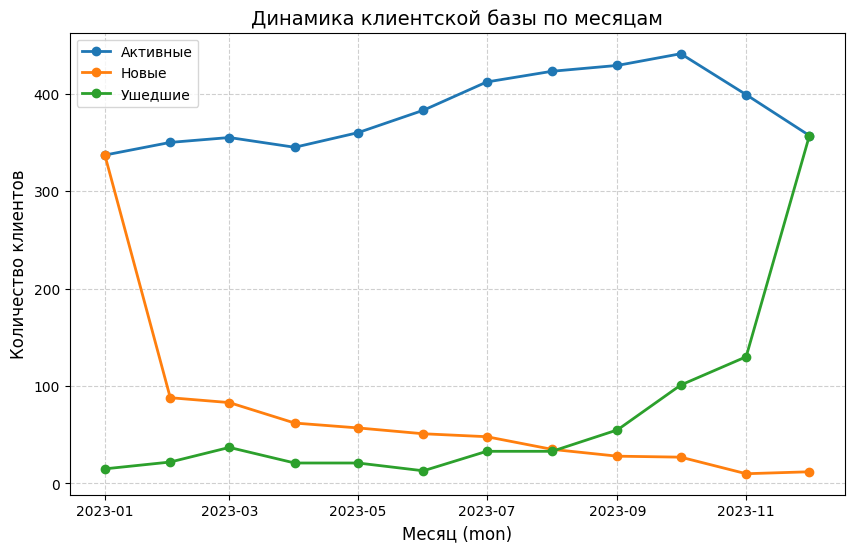

In [94]:
#Строим линейный график
# Настраиваем размер графика
plt.figure(figsize=(10, 6))

# Рисуем три линии
plt.plot(final_df['mon'], final_df['active_clients'], label='Активные', marker='o', linewidth=2)
plt.plot(final_df['mon'], final_df['new_clients'], label='Новые', marker='o', linewidth=2)
plt.plot(final_df['mon'], final_df['gone_clients'], label='Ушедшие', marker='o', linewidth=2)

# Добавляем подписи и красивое оформление
plt.title('Динамика клиентской базы по месяцам', fontsize=14)
plt.xlabel('Месяц (mon)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Добавляем сетку
plt.legend() # Добавляем легенду (обозначение линий)

# Показываем график на экране
plt.show()